In [5]:
import pandas as pd
import numpy as np
import os
import gc # Thư viện dọn rác bộ nhớ

# 1. Cấu hình đường dẫn (từ thư mục notebooks trỏ ra ngoài)
RAW_DIR = '../dataset/raw/'
PROCESSED_DIR = '../dataset/processed/'

# Đảm bảo thư mục processed tồn tại
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 2. Hàm ép cân dữ liệu (Giảm 50-70% RAM)
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'---> Dung lượng ban đầu: {start_mem:.2f} MB')
    for col in df.columns:
        col_type = df[col].dtype
        
        # [CẬP NHẬT] Bỏ qua cột thời gian (datetime) VÀ cột phân loại (category)
        if pd.api.types.is_datetime64_any_dtype(col_type) or str(col_type) == 'category':
            continue
            
        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
        else:
            # Chuyển kiểu object (chuỗi) sang category để tiết kiệm bộ nhớ
            df[col] = df[col].astype('category')
            
    print(f'---> Dung lượng sau khi tối ưu: {df.memory_usage().sum() / 1024**2:.2f} MB')
    return df

# ==========================================
# THỰC THI XỬ LÝ DỮ LIỆU
# ==========================================

print("1. Đang tải dữ liệu Calendar...")
calendar = pd.read_csv(os.path.join(RAW_DIR, 'calendar.csv'))
calendar = reduce_mem_usage(calendar)

print("\n2. Đang tải dữ liệu Sales...")
# MẸO: Lần chạy đầu tiên, hãy giữ `nrows=5000` để test xem code chạy có lỗi không. 
# Khi đã chạy thành công, bạn XÓA `nrows=5000` đi và chạy lại để xử lý toàn bộ data.
sales = pd.read_csv(os.path.join(RAW_DIR, 'sales_train_validation.csv'), nrows=5000) 

print("\n3. Đang Melt (kéo giãn) dữ liệu Sales...")
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
sales_melted = pd.melt(sales, id_vars=id_vars, var_name='d', value_name='demand')

# Dọn dẹp biến sales cũ để giải phóng RAM
del sales
gc.collect()

print("\n4. Đang Merge Sales với Calendar...")
df_master = pd.merge(sales_melted, calendar, on='d', how='left')

# Xóa bớt các biến tạm
del sales_melted
del calendar
gc.collect()

# Đổi cột date sang định dạng thời gian chuẩn
df_master['date'] = pd.to_datetime(df_master['date'])

print("\n5. Ép cân lần cuối cho DataFrame tổng...")
df_master = reduce_mem_usage(df_master)

print("\n6. Đang lưu dữ liệu đã xử lý...")
# Lưu ra file Parquet để đọc siêu nhanh cho các bước sau
processed_file_path = os.path.join(PROCESSED_DIR, 'master_data.parquet')
df_master.to_parquet(processed_file_path, index=False)

print(f"✅ Hoàn tất! File đã được lưu tại: {processed_file_path}")
print("\nHiển thị 5 dòng đầu tiên:")
display(df_master.head())

1. Đang tải dữ liệu Calendar...
---> Dung lượng ban đầu: 0.21 MB
---> Dung lượng sau khi tối ưu: 0.19 MB

2. Đang tải dữ liệu Sales...

3. Đang Melt (kéo giãn) dữ liệu Sales...

4. Đang Merge Sales với Calendar...

5. Ép cân lần cuối cho DataFrame tổng...
---> Dung lượng ban đầu: 784.49 MB
---> Dung lượng sau khi tối ưu: 310.48 MB

6. Đang lưu dữ liệu đã xử lý...
✅ Hoàn tất! File đã được lưu tại: ../dataset/processed/master_data.parquet

Hiển thị 5 dòng đầu tiên:


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


Đang load dữ liệu từ file Parquet...
Đang phân tích mặt hàng: HOBBIES_1_001 | Cửa hàng: CA_1


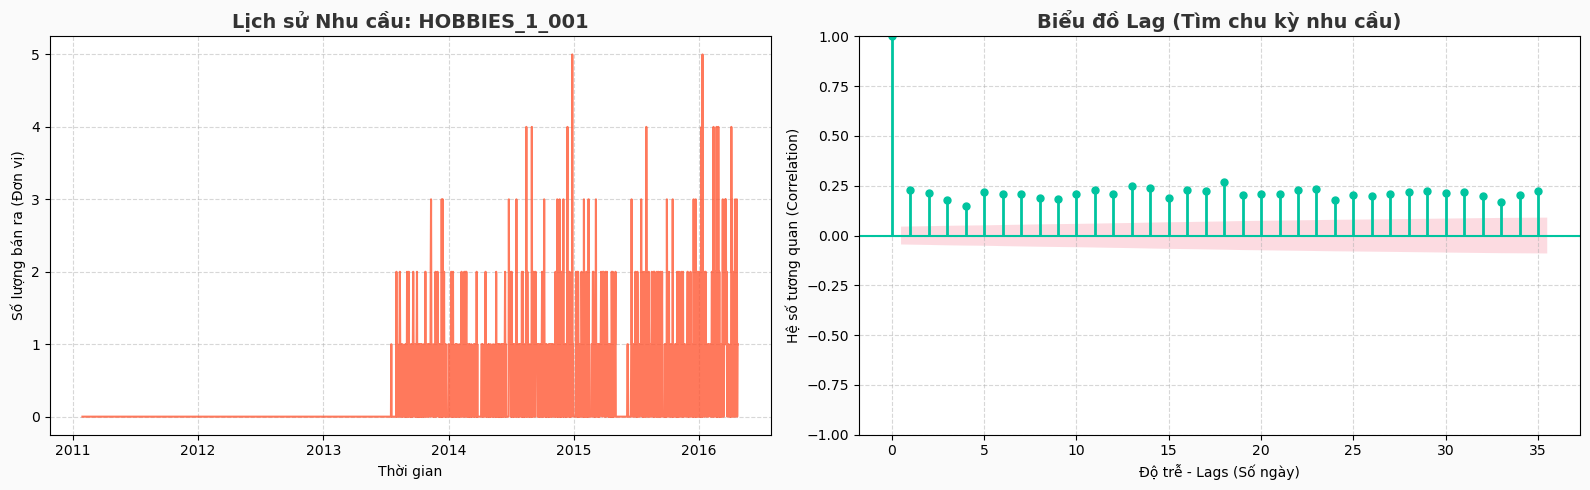

In [6]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Tắt các cảnh báo màu đỏ cho đẹp notebook

# 1. Đọc dữ liệu siêu tốc từ file Parquet vừa tạo
print("Đang load dữ liệu từ file Parquet...")
PROCESSED_DIR = '../dataset/processed/'
df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'master_data.parquet'))

# 2. Cài đặt font và màu sắc cho biểu đồ thật chuyên nghiệp
plt.style.use('seaborn-v0_8-pastel')
sns.set_palette("husl")

def plot_demand_lag(df, item_id, store_id, lags=35):
    """
    Hàm vẽ lịch sử nhu cầu và biểu đồ tự tương quan (Lag Chart)
    """
    print(f"Đang phân tích mặt hàng: {item_id} | Cửa hàng: {store_id}")
    
    # Lọc dữ liệu của đúng 1 mặt hàng tại 1 cửa hàng
    item_data = df[(df['item_id'] == item_id) & (df['store_id'] == store_id)].copy()
    item_data = item_data.sort_values('date')
    
    if item_data.empty:
        print("❌ Không tìm thấy dữ liệu! Hãy kiểm tra lại mã item_id hoặc store_id.")
        return

    # Khởi tạo khung tranh vẽ 2 biểu đồ cạnh nhau
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#FAFAFA')
    
    # --- Biểu đồ 1: Lịch sử bán hàng thực tế ---
    axes[0].plot(item_data['date'], item_data['demand'], color='#FF5733', linewidth=1.5, alpha=0.8)
    axes[0].set_title(f'Lịch sử Nhu cầu: {item_id}', fontsize=14, fontweight='bold', color='#333')
    axes[0].set_xlabel('Thời gian')
    axes[0].set_ylabel('Số lượng bán ra (Đơn vị)')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # --- Biểu đồ 2: Lag Chart (Tự tương quan) ---
    plot_acf(item_data['demand'], lags=lags, ax=axes[1], color='#00C49F', vlines_kwargs={'colors': '#00C49F', 'linewidth': 2})
    axes[1].set_title(f'Biểu đồ Lag (Tìm chu kỳ nhu cầu)', fontsize=14, fontweight='bold', color='#333')
    axes[1].set_xlabel('Độ trễ - Lags (Số ngày)')
    axes[1].set_ylabel('Hệ số tương quan (Correlation)')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    # Căn chỉnh và hiển thị
    plt.tight_layout()
    plt.show()

# 3. Chạy thử hàm với mặt hàng đầu tiên có trong tập dữ liệu của bạn
# Lấy tự động mã sản phẩm và cửa hàng dòng đầu tiên để test
sample_item = df['item_id'].iloc[0]
sample_store = df['store_id'].iloc[0]

plot_demand_lag(df, item_id=sample_item, store_id=sample_store, lags=35)